In [1]:
from pathlib import Path

def path_translator(experiement_name):


    result_folder = Path("../../Simulation_results/")
    file_name = "analyzed_" + experiement_name + ".csv"
    results_path = result_folder / experiement_name / file_name

    return results_path

In [ ]:
    \item knotsmat  : 
    \item WCEmat : 
    \item loglik : 
    \item coef : 
    \item vcovmat : 
    \item SE : 
    \item covariates : 
    \item constrained : 
    \item nevents : 
    \item aic : 
    \item info.criterion : 
    \item nknots : 
    \item confint : 
    \item nbootstraps : 

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [3]:
path = Path("../../R")

In [9]:
! ls

 analysis_05-03-2024.ipynb     analysis_2025-03-10.ipynb
 analysis_12-03-2024.ipynb     benchmark_simulation.png
 analysis_19-03-2024.ipynb     better_heatmap.ipynb
'analysis_2024-04-23 .ipynb'  'statistical_exploration_2024_11_22 copy.ipynb'


In [4]:
data_survivalgpu_gpu = pd.read_csv(path / "benchmark_survivalgpu_gpu.csv")
data_survivalgpu_cpu = pd.read_csv(path / "benchmark_survivalgpu_cpu.csv")

# data_survivalgpu_gpu = data_survivalgpu_gpu.iloc[1:].reset_index(drop=True)
# data_survivalgpu_cpu = data_survivalgpu_cpu.iloc[1:].reset_index(drop=True)

In [6]:
data_wceR_cpu = pd.read_csv(path / "benchmark_wce_cpu.csv")
# data_wceR_cpu = data_wceR_cpu.iloc[1:].reset_index(drop=True)

In [7]:
data_wceR_cpu

,n_patients,time_cpu
0,100,0.057033
1,200,0.192431
2,500,1.093659
3,1000,3.270168
4,2000,8.364420
5,5000,31.042399
6,10000,89.273403
7,20000,312.659476
8,50000,1950.000000
9,100000,9321.705942


In [13]:
data_survivalgpu_gpu

,n_patients,time_cpu
0,100,0.764663
1,200,0.732669
2,500,0.969993
3,1000,1.098262
4,2000,1.324096
5,5000,2.064536
6,10000,3.392474
7,20000,5.067656
8,50000,11.134176
9,100000,20.916440


NameError: name 'data_wceR_cpu' is not defined

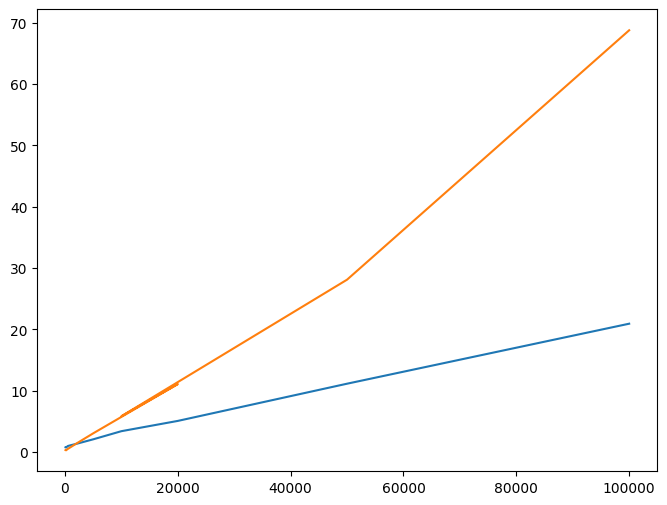

In [6]:
plt.figure(figsize=(8, 6))
from matplotlib.ticker import FuncFormatter


def time_formatter(x, pos):
    if x < 1:  # less than 1 second, show in ms
        return f"{x * 1000:.0f} ms"
    elif x < 60:  # less than 60 seconds, show in seconds
        return f"{x:.0f} s"
    elif x < 3600:  # less than 3600 seconds, show in minutes
        return f"{x / 60:.0f} min"
    else:  # show in hours
        return f"{x / 3600:.1f} hr"


# Plot lines
plt.plot(data_survivalgpu_gpu["n_patients"], data_survivalgpu_gpu["time_cpu"], linestyle="-")
plt.plot(data_survivalgpu_cpu["n_patients"], data_survivalgpu_cpu["time_cpu"], linestyle="-")
plt.plot(data_wceR_cpu["n_patients"], data_wceR_cpu["time_cpu"], linestyle="-")

# Scatter points for real data
plt.scatter(data_survivalgpu_gpu["n_patients"], data_survivalgpu_gpu["time_cpu"], label="Survivalgpu package with GPU", marker="o")
plt.scatter(data_survivalgpu_cpu["n_patients"], data_survivalgpu_cpu["time_cpu"], label="Survivalgpu package with CPU", marker="s")
plt.scatter(data_wceR_cpu["n_patients"], data_wceR_cpu["time_cpu"], label="WCE package", marker="^")

plt.grid(True, which="major", linestyle="-")
plt.grid(True, which="minor", linestyle="dotted")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of patients")
plt.ylabel("Computation time (s)")
plt.title("Benchmark of WCE and SurvivalGPU packages")
plt.legend()

# Format X-axis to show logarithmic scale with specific tick labels
ax = plt.gca()
ax.set_xticks([100,200,500, 1000,2000, 5000, 10000, 20000,50000, 100000])
ax.set_xticklabels([f"{int(x):,}" for x in [100,200,500, 1000,2000, 5000, 10000, 20000,50000, 100000]])


# plt.gca().yaxis.set_major_formatter(FuncFormatter(time_formatter))


plt.show()


# Save the figure without background white
fig = ax.get_figure()
fig.patch.set_alpha(0.0)

slide_path = Path("/home/apoirotb/dev/Inria/Notes/Slides/")


prez_name = "Point_emmanuel_bacry"



image_name = "benchmark.png"

image_path= slide_path / prez_name / "images" / image_name


fig.savefig(image_path , transparent=True)



In [8]:
! pwd

/home/apoirotb/dev/Inria/survivalGPU/simulations/python/data_analysis


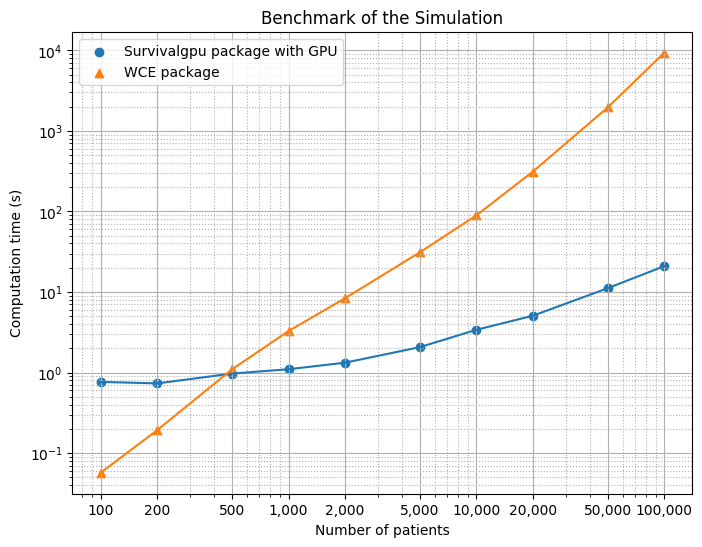

In [36]:
plt.figure(figsize=(8, 6))

# Plot lines
plt.plot(data_survivalgpu_gpu["n_patients"], data_survivalgpu_gpu["time_cpu"], linestyle="-")
# plt.plot(data_survivalgpu_cpu["n_patients"], data_survivalgpu_cpu["time_cpu"], linestyle="-")
plt.plot(data_wceR_cpu["n_patients"], data_wceR_cpu["time_cpu"], linestyle="-")

# Scatter points for real data
plt.scatter(data_survivalgpu_gpu["n_patients"], data_survivalgpu_gpu["time_cpu"], label="Survivalgpu package with GPU", marker="o")
# plt.scatter(data_survivalgpu_cpu["n_patients"], data_survivalgpu_cpu["time_cpu"], label="Survivalgpu package with CPU", marker="s")
plt.scatter(data_wceR_cpu["n_patients"], data_wceR_cpu["time_cpu"], label="WCE package", marker="^")

plt.grid(True, which="major", linestyle="-")
plt.grid(True, which="minor", linestyle="dotted")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of patients")
plt.ylabel("Computation time (s)")
plt.title("Benchmark of the Simulation")
plt.legend()

# Format X-axis to show logarithmic scale with specific tick labels
ax = plt.gca()
ax.set_xticks([100,200,500, 1000,2000, 5000, 10000, 20000,50000, 100000])
ax.set_xticklabels([f"{int(x):,}" for x in [100,200,500, 1000,2000, 5000, 10000, 20000,50000, 100000]])

plt.show()